In [24]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import chardet
# Download NLTK resources
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [25]:
elon_musk_tweets = pd.read_csv("Elon_musk.csv")

In [26]:
# Assingning collection words
with open("positive-words.txt", "rb") as file:
    positive_encoding = chardet.detect(file.read())["encoding"]

with open("negative-words.txt", "rb") as file:
    negative_encoding = chardet.detect(file.read())["encoding"]

with open("stop.txt", "rb") as file:
    stop_encoding = chardet.detect(file.read())["encoding"]

In [27]:
# Initialize Sentiment Intensity Analyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [28]:
elon_musk_tweets['Sentiment'] = elon_musk_tweets['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [29]:
elon_musk_tweets['Sentiment_Label'] = elon_musk_tweets['Sentiment'].apply(lambda x: 'Positive' if x > 0 else ('Neutral' if x == 0 else 'Negative'))

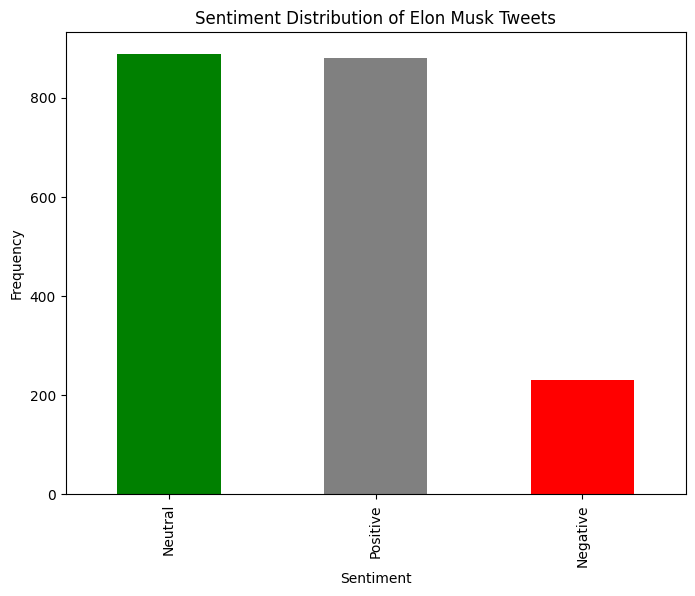

In [30]:
plt.figure(figsize=(8, 6))
elon_musk_tweets['Sentiment_Label'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution of Elon Musk Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

In [31]:
from wordcloud import WordCloud
positive_text = " ".join(elon_musk_tweets[elon_musk_tweets['Sentiment_Label'] == 'Positive']['Text'])
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

negative_text = " ".join(elon_musk_tweets[elon_musk_tweets['Sentiment_Label'] == 'Negative']['Text'])
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(negative_text)

(-0.5, 799.5, 399.5, -0.5)

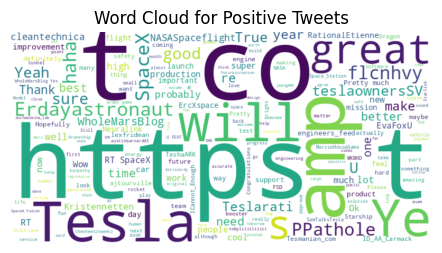

In [32]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Tweets')
plt.axis('off')


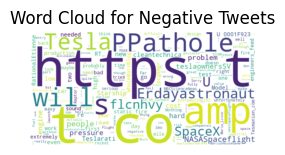

In [33]:
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Tweets')
plt.axis('off')
plt.show()

In [34]:
# N-grams and TF-IDF Vectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words='english')
ngram_matrix = ngram_vectorizer.fit_transform(elon_musk_tweets['Text'])

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(elon_musk_tweets['Text'])

In [35]:
def plot_top_ngrams(matrix, vectorizer, title):
    ngrams_sum = matrix.sum(axis=0)
    ngrams_freq = [(word, ngrams_sum[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    ngrams_freq = sorted(ngrams_freq, key=lambda x: x[1], reverse=True)[:10]

    plt.figure(figsize=(10, 6))
    plt.bar([word[0] for word in ngrams_freq], [word[1] for word in ngrams_freq], color='skyblue')
    plt.title(title)
    plt.xlabel('N-gram')
    plt.ylabel('Frequency')
    plt.show()

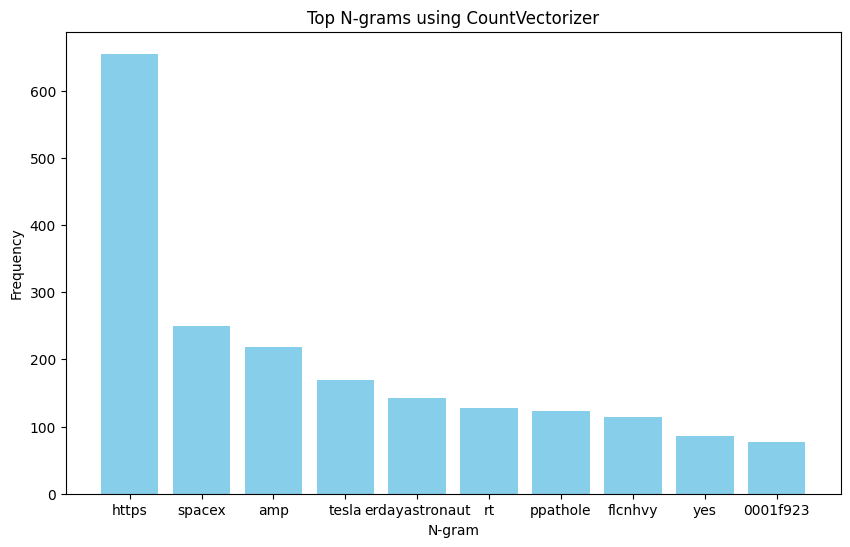

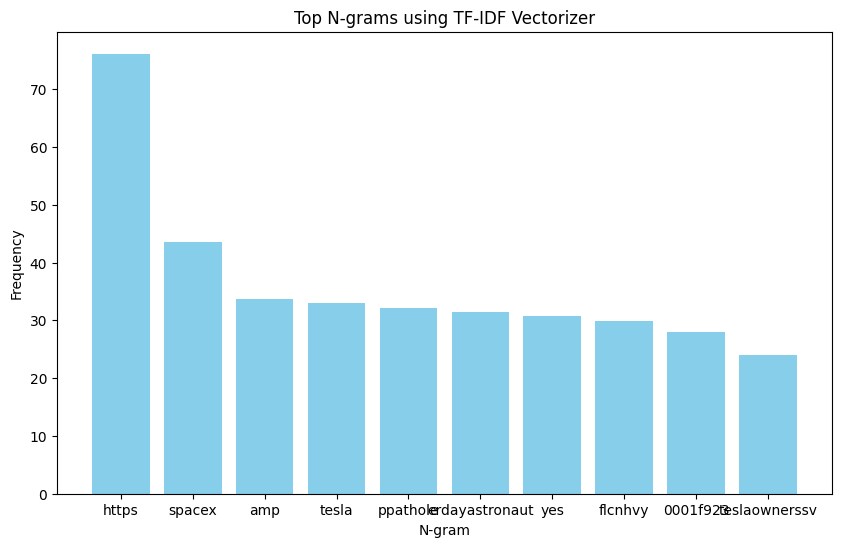

In [36]:
plot_top_ngrams(ngram_matrix, ngram_vectorizer, 'Top N-grams using CountVectorizer')
plot_top_ngrams(tfidf_matrix, tfidf_vectorizer, 'Top N-grams using TF-IDF Vectorizer')

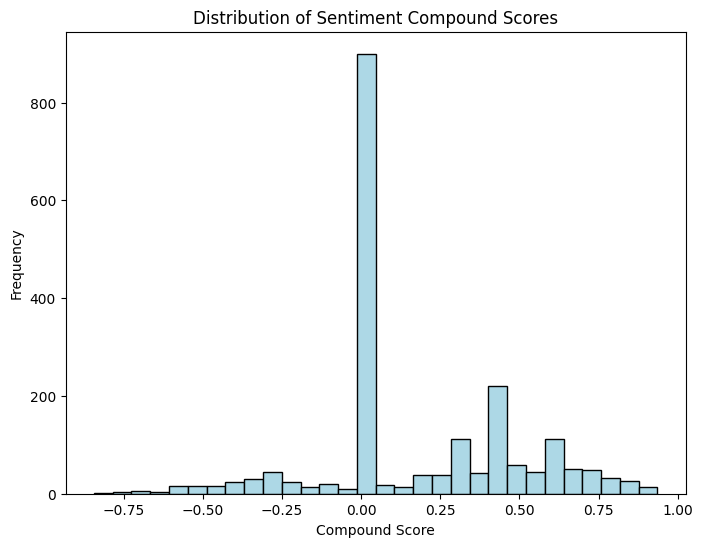

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(elon_musk_tweets['Sentiment'], bins=30, color='lightblue', edgecolor='black')
plt.title('Distribution of Sentiment Compound Scores')
plt.xlabel('Compound Score')
plt.ylabel('Frequency')
plt.show()


In [38]:
labels = elon_musk_tweets['Sentiment_Label'].value_counts().index
sizes = elon_musk_tweets['Sentiment_Label'].value_counts().values
colors = ['green', 'gray', 'red']

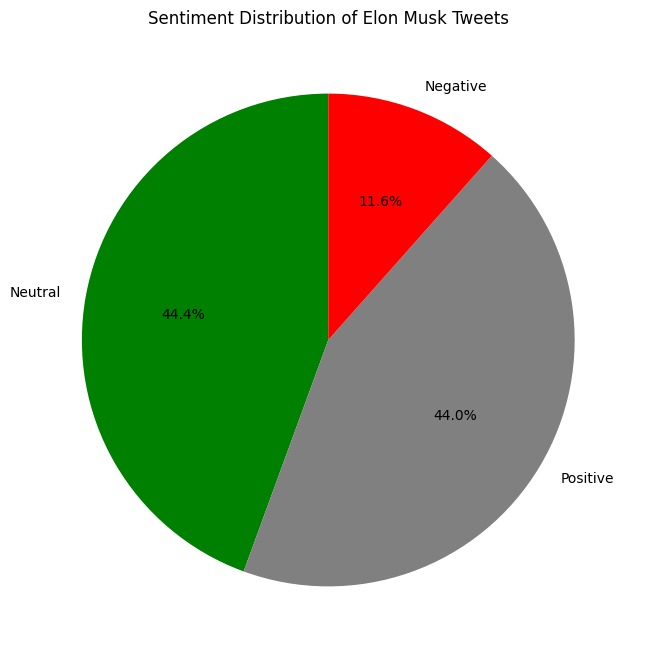

In [39]:
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Sentiment Distribution of Elon Musk Tweets')
plt.show()
